<a href="https://colab.research.google.com/github/inferencialestadistica76/EstadisticaVerano2026/blob/main/StudentPerformance2/student_perfomance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/inferencialestadistica76/EstadisticaVerano2026/refs/heads/main/studentperfomance/Student_Performance.csv")

df

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


Establecemos las horas de estudio ("hours_studied") como variable dependiente y el indice de desempeño ("permonce_index") como la variable independiente. Esto es porque la hipotesis inicial es que cambios en las horas de estudio puede cambiar cambios en el indice de desempeño, sin embargo cambios en los indices de desempeño no causa cambios en las horas de estudio.

In [47]:
X = df["Hours_Studied"]        #variable independiente
Y = df["Performance_Index"]       #variable dependiente

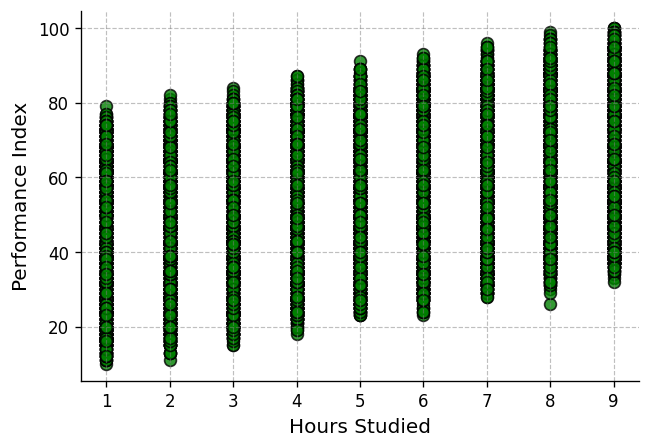

In [48]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='green',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hours Studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance Index', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)


El gráfico de dispersión muestra una clara tendencia lineal. Se puede observar que conforme aumentan las horas de estudio ($X$) aumenta el índice de desempeño ($Y$). Con lo que se espera un coeficiente de correlación positivo y parece cumplirse el supuesto de linealidad.


In [49]:
# Importar la funcion pearsonr desde scipy stats
from scipy.stats import pearsonr
# Test de Pearson
# H0: rho = 0    (No hay correlación)
# H1: rho != 0    (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)
print(f"Coeficiente de correlación: {r:0.4f}")
print(f'Valor p: {valor_p:0.4f}')

Coeficiente de correlación: 0.3737
Valor p: 0.0000


El coeficiente de correlación $r=0.3737$ indica una correlación lineal débil, sin embargo, haber una relación débil si existe correlación


In [50]:
import statsmodels.api as sm

x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,41.379175
Hours_Studied,2.773063


In [51]:
# Coeficiente de determinacion
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)
print(f"Coeficiente de determinacion: {r2: 0.2%}")

Coeficiente de determinacion:  13.97%


Una vez ajustado el modelo de regresión lienal, se obtiene un coeficiente de determinación de $R^2=0.1397$.
entonces teniendo las horas de estudio y el modelo ajustado, sólo podemos justificar la variabilidad en las calificaciones en un 13.97%, lo que es muy bajo para poder realizar predicciones precisas.


La ecuación de la recta es:

$$\hat
y=41.379175 + 2.773063x
$$


Este modelo estima que, la calificación base (
) es de aproximadamente
. Lo que significa que si un estudiante no estudia, se espera que obtenga un índice de desempeño con ese valor. Mientras que una pendiente de 2.77, indica que por cada hora estudiada se espera un aumento en la calificación de aproximadamente 2.77.

In [52]:
modelo.params


,0
const,41.379175
Hours_Studied,2.773063


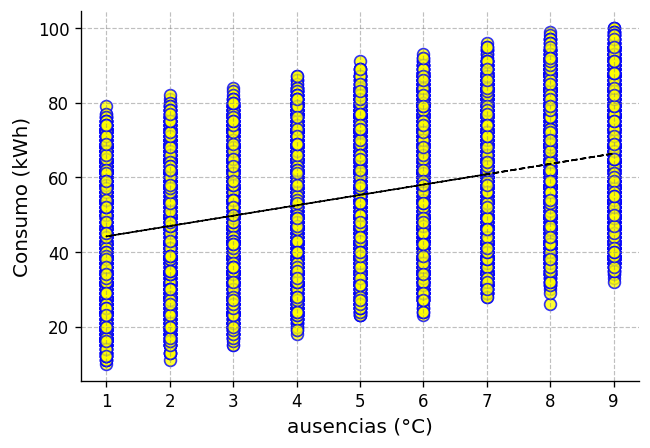

In [53]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='yellow',     # color de los puntos
    edgecolor='blue',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'ausencias (°C)', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Consumo (kWh)', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

La recta de regresión ajustada obtenida es muy consistente con las observaciones. Se esperaba una relación positiva. Sin embargo, se observa una gran dispersión en los datos, lo que causa que el coeficiente de determinación sea tan bajo.

In [54]:

modelo.conf_int(alpha=0.05)



,0,1
const,40.620341,42.138008
Hours_Studied,2.638143,2.907983


La interción tiene un intervalo de confianza del 95% de **[40.62, 42.14]**. Esto significa que se tiene un nivel de confianza de 95% de que la calificación esperada para el estudiante que no estudió está entre estos valores. Por otra parte, según el intervalo de confianza de la pendiente, se espera que un estudiante gane entre 2.64 y 2.91 puntos en su índice de desempeño por cada hora de estudio. Esto con una confianza del 95%.

In [55]:
residuales = modelo.resid

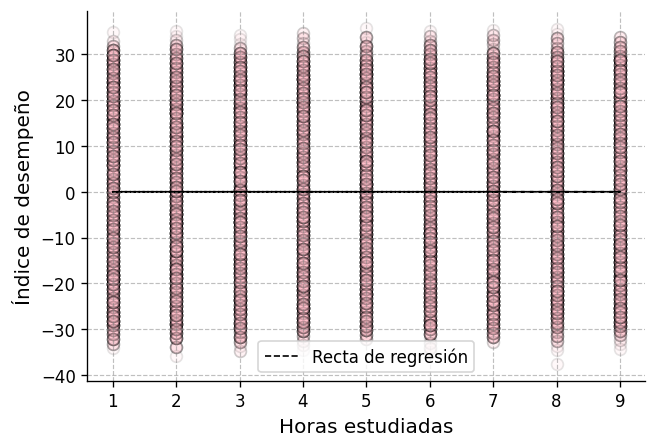

In [56]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      #
    marker="o",       # forma: googlear "matplotlib.markers"
    color='pink',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.1,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Horas estudiadas', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Índice de desempeño', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Los residuales parecen reforzar la idea de que los datos siguen una tendencia lineal. Los puntos parecen tener un color más intenso cercanos a la recta y más difuminados alejados de ella, por lo que también podrían cumplir con una distribución normal. Además, los datos parecen cumplir cavalmente con la homoscedasticidad. Sin embargo, pese a lo que se observa, se realizarán las pruebas estadísticas

valor-p (Shapiro) = 2.3269507843403982e-45


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


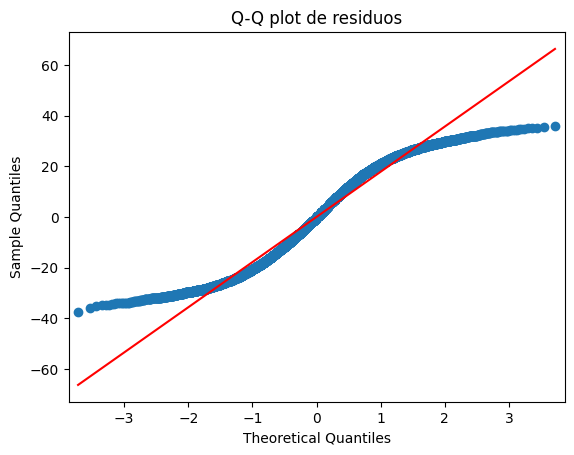

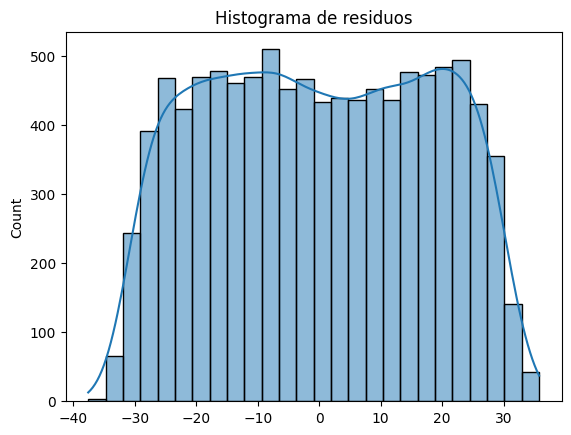

In [57]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el mas confiable
# n >= 30, Histograma o Q-Q plot

#test de shapiro-Wilk
# 1
#Ho:Hay normalidad   0.4172971767713699
# 0.05 (Assuming this was intended as alpha value or a note)
#Hi:No hay normalidad
# 0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Según el gráfico de cuantil-cuantil y el histograma, los residuales parecen cumplir con una distribución uniforme y no una distribución normal.Según el gráfico de cuantil-cuantil y el histograma, los residuales parecen cumplir con una distribución uniforme y no una distribución normal.

In [58]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.9742



Pero la suposición de homoscedasticidad sí se ve reforzada por la prueba de Breusch-Pagan.